# Classification - LDA
----


Logistic regression 방법은 $\mathbb P (Y=k | X=x)$의 확률을 계산하는 것이었다.

Linear discriminant analysis에서는 주어진 $Y$에 대해 $X$의 분포를 추정한다.

만약 $X$의 분포가 (각 클래스에서 공통의 공분산 행렬을 갖는) 정규분포라고 하면, 이 방법은 logistic regression과 매우 흡사하다.

다음의 상황에서 linear discriminant analysis가 유용하게 사용될 수 있다.

* 클래스들이 잘 분리되어 있을 때, logistic regression의 모수 추정은 불안정한 경우가 많다. 이 경우 LDA가 더 좋다.

* 데이터의 개수가 상대적으로 작고, $X$의 분포가 정규분포와 흡사할 때, LDA가 logistic regression 보다 잘 작동하는 경우가 많다.

* 2개가 넘는 클래스가 있을 때도, LDA는 자연스럽게 확장되어 사용 가능하다.

## Bayes 정리와 LDA 

LDA는 Bayes 정리를 기반으로 한다.

$Y$가 $K$개의 클래스를 가질 수 있다고 하자.

$\pi_k$를 임의로 선택한 관찰 결과가 $k$에 속하게 될, 사전 확률 (prior probability)이라고 하자.

* 즉, 이 확률은 $X$에 대한 정보 없이 결정된 확률이다.

$Y$가 $k$의 클래스에 속할 때, $X$의 확률밀도함수를 다음과 같이 정의하자.

$$ f_k(x) = \mathbb P (X=x | Y=k) $$

Bayes 정리에 따르면,

$$ \mathbb P(Y = k | X = x) = \frac{\pi_k f_k(x)}{\sum_{l=1}^{K} \pi_l f_l(x)} $$

한편, $p_k(x) = \mathbb P(Y = k | X = x)$라고 하겠다. 이를 사후 확률, posterior probability 라고도 한다.

이전에는 $p_k$를 직접 계산하는 것이 목표였다면, LDA에서는 $\pi$들과 $f$들을 추정하여, $p_k$를 추정한다.

  * 사전 확률 $\pi_k$: 클래스 비율로부터 간단히 추정 가능하다.
    
  * 클래스별 밀도 함수 $f_k(x)$: 일반적으로는 추정이 어렵지만, LDA에서는 각 클래스의 $X$가 정규분포를 따른다는 가정을 통해 간단하게 추정 가능하다


### (참고) 일반적인 Bayes 정리 

서로 배반(disjoint)이며 전체 표본공간을 구성하는 사건 $A_1, A_2, \dots, A_K$가 있을 때, 즉

$$
\bigcup_{k=1}^{K} A_k = \Omega, \quad A_k \cap A_l = \emptyset \quad \text{for } k \neq l,
$$

임의의 사건 $B$에 대해 Bayes 정리는 다음과 같이 쓸 수 있다.

$$
\mathbb{P}(A_k \mid B) = \frac{\mathbb{P}(B \mid A_k)\mathbb{P}(A_k)}{\sum_{l=1}^{K} \mathbb{P}(B \mid A_l)\mathbb{P}(A_l)}
$$

여기서,

* 분모 $\mathbb{P}(B) = \sum_{l=1}^{K} \mathbb{P}(B \mid A_l)\mathbb{P}(A_l)$는 총확률의 법칙에 의해 도출된 것,
* 위 식은 분모를 명시적으로 확장하여, 다수의 가능한 원인(또는 클래스)에 대해 정규화된 형태로 나타낸 Bayes 정리의 확장된 표현

## Linear Discriminant Analysis when $p = 1$

$Y$가 $k$번째 클래스에 속할 때, $X$의 조건부 확률 밀도 함수 $f_k(x)$를 정규분포로 가정하자.

$$
f_k(x) = \frac{1}{\sqrt{2 \pi} \sigma_k} \exp\left( -\frac{1}{2} \left( \frac{x - \mu_k}{\sigma_k} \right)^2 \right)
$$

여기서 $\mu_k$는 클래스 $k$의 평균, $\sigma_k^2$는 분산이다.

LDA에서는 **클래스 간 분산이 동일**하다고 가정하여 $\sigma_k = \sigma$로 놓는다.


Bayes 정리에 따르면 사후 확률 $p_k(x) = \mathbb{P}(Y = k \mid X = x)$는 다음과 같이 주어진다.

$$
p_k(x) = \frac{\pi_k \cdot \frac{1}{\sqrt{2 \pi} \sigma} \exp\left( -\frac{1}{2} \left( \frac{x - \mu_k}{\sigma} \right)^2 \right)}{\sum_{l=1}^{K} \pi_l \cdot \frac{1}{\sqrt{2 \pi} \sigma} \exp\left( -\frac{1}{2} \left( \frac{x - \mu_l}{\sigma} \right)^2 \right)}
$$

분류 문제에서 관심 있는 것은 $x$에 대해 어떤 $p_k(x)$가 가장 큰가이다.

비교를 용이하게 하기 위해 **로그 변환**을 하고 상수항을 제거하여, 다음과 같은 **discriminant score** $\delta_k(x)$를 도출한다.

$$
\delta_k(x) = x \cdot \frac{\mu_k}{\sigma^2} - \frac{\mu_k^2}{2\sigma^2} + \log(\pi_k)
$$

이때,

* $p_k(x)$ 중에서 최대를 찾는 것과
* $\delta_k(x)$ 중에서 최대를 찾는 것은 **동치**이다.

따라서 분류는 $x$를 $\delta_k(x)$가 가장 큰 클래스 $k$에 할당하는 것으로 수행된다.

한편, $\delta_k(x)$는 $x$에 대한 **선형 함수**이므로, 이 모형이 "Linear" Discriminant Analysis라 불리는 이유다.

그리고, 확률 계산은 discriminant score에 softmax 함수를 적용한 것과 동치이다.

즉,

$$ p_k (x) = \frac{e^{\delta_k (x)}}{\sum_{i=1}^K e^{\delta_i (x)}} $$


예를 들어, $K = 2$이고 사전 확률이 동일하게 $\pi_1 = \pi_2 = 0.5$일 경우, 결정 경계는 다음과 같이 단순해진다.

$$
x = \frac{\mu_1 + \mu_2}{2}
$$

이는 두 클래스 평균의 중간값이다.




### 모수 추정

실제로는 모수들 $\pi_k, \mu_k, \sigma$를 알 수 없기 때문에, 주어진 학습 데이터를 바탕으로 다음과 같이 추정하여 사용한다:

$$
\begin{aligned}
\hat{\pi}_k &= \frac{n_k}{n}, \quad &\text{(클래스 비율)} \\
\hat{\mu}_k &= \frac{1}{n_k} \sum_{i: y_i = k} x_i, \quad &\text{(클래스 평균)} \\
\hat{\sigma}^2 &= \frac{1}{n - K} \sum_{k=1}^{K} \sum_{i: y_i = k} (x_i - \hat{\mu}_k)^2, \quad &\text{(공통 분산)}
\end{aligned}
$$

여기서,

* $n_k$: 클래스 $k$에 속한 샘플 수,
* $n$: 전체 샘플 수.

## Linear Discriminant Analysis when $p > 1$

LDA는 $p > 1$인 다변량 입력에 대해서도 확장할 수 있으며, 이때는 **다변량 정규분포**(multivariate normal distribution)를 이용한다.

다변량 정규분포의 확률밀도함수는 다음과 같다:

$$
f(x) = \frac{1}{(2\pi)^{p/2} |\Sigma|^{1/2}} \exp \left(-\frac{1}{2} (x - \mu)^{\top} \Sigma^{-1} (x - \mu) \right)
$$

여기서

* $\mu$는 $p$-차원 평균 벡터,
* $\Sigma$는 $p \times p$ 공분산 행렬,
* $|\Sigma|$는 행렬식(determinant)이다.

LDA에서는 클래스 $k$에 대응되는 $X$의 조건부 분포가 다음과 같이 가정된다:

$$
X \mid Y = k \enspace \sim \enspace  \mathcal{N}(\mu_k, \Sigma)
$$

* 즉, 각 클래스마다 **다른 평균 벡터** $\mu_k$를 가지지만,
* **공통의 공분산 행렬** $\Sigma$를 공유한다고 가정한다.

> 이 가정은 LDA의 핵심이며, 이를 통해 결정 경계가 선형이 되도록 유도된다.

이 가정과 Bayes 정리를 바탕으로 도출되는 **discriminant score**는 다음과 같다:

$$
\delta_k(x) = x^{\top} \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^{\top} \Sigma^{-1} \mu_k + \log \pi_k
$$

* 첫 항: $x$에 대해 **선형**임
* 둘째 항: $x$와 무관한 상수
* 셋째 항: 사전확률 기반 상수

따라서 $\delta_k(x)$는 $x$에 대한 **선형 함수**이며,
$x$가 주어졌을 때 $\delta_k(x)$가 가장 큰 클래스를 선택하게 된다.


### 예시

아래 그림은 $\pi_1 = \pi_2 = \pi_3 = \frac{1}{3}$일 때의 LDA 분류 경계선 예시이다:

* **점선**: 실제 데이터 생성 분포를 알고 있다고 가정할 때의 **Bayes optimal decision boundary**
* **실선**: LDA의 가정(정규분포 + 동일 공분산 행렬)에 따라 학습된 **LDA decision boundary**

실제 분포와 근사된 LDA 경계가 얼마나 유사한지를 시각적으로 비교할 수 있다.

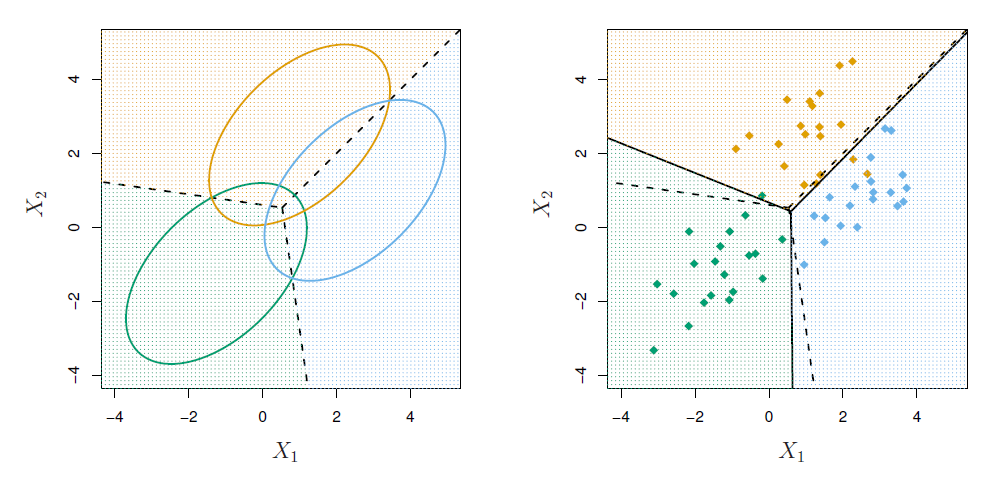

데이터로부터 $\hat \delta_k (x)$가 추정되면, 소프트맥스 함수를 이용해 각 클래스에 대한 확률 추정에 사용할 수 있다.

$$ \hat{\mathbb P} (Y=k | X=x) = \frac{e^{\hat \delta_k (x)}}{\sum_{l = 1}^{K} e^{\hat \delta_{l}(x)}} $$

## [Wine dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)을 이용한 예제

In [1]:
from sklearn import datasets
import pandas as pd
import numpy as np
raw_wine = datasets.load_wine()

In [2]:
raw_wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [3]:
raw_wine["feature_names"]

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [4]:
pd.DataFrame(raw_wine["data"], columns = raw_wine["feature_names"])

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


alcohol과 malic_acid를 이용하여 와인의 종류를 예측하는 예제를 진행해 보자.

In [5]:
X, y  = raw_wine.data[:,:2], raw_wine.target

In [6]:
pd.DataFrame(np.c_[X, y],  columns = ["alcohol", "malic_acid", "y"])

,alcohol,malic_acid,y
0,14.23,1.71,0.0
1,13.20,1.78,0.0
2,13.16,2.36,0.0
3,14.37,1.95,0.0
4,13.24,2.59,0.0
...,...,...,...
173,13.71,5.65,2.0
174,13.40,3.91,2.0
175,13.27,4.28,2.0
176,13.17,2.59,2.0


Logistic regression 예제에서는 데이터의 전부를 모형 훈련에 사용하였지만, 이 예제에서는 훈련 데이터와 테스트 데이터를 분할하여 사용하여 보자.  

[```sklearn.model_selection.train_test_split```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)을 이용하면, 데이터를 쉽게 분할할 수 있다.

- 기본 설정으로 75:25로 train/test set을 나눈다.  
- `test_size` 매개변수를 설정하여 비율 조절 가능. 
- `stratify=y`를 지정하면 분할 후에도 각 클래스의 비율이 원본 데이터와 비슷하게 유지된다 (클래스 불균형이 있는 데이터에서 특히 유용하다).

In [7]:
# 트레이닝 테스트 데이터 분할
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, stratify=y)

In [8]:
pd.DataFrame(np.c_[X_tn, y_tn],  columns = ["alcohol", "malic_acid", "y"])

,alcohol,malic_acid,y
0,13.83,1.65,0.0
1,13.90,1.68,0.0
2,13.82,1.75,0.0
3,13.73,1.50,0.0
4,13.40,3.91,2.0
...,...,...,...
128,12.08,2.08,1.0
129,13.50,3.12,2.0
130,13.11,1.01,1.0
131,12.64,1.36,1.0


In [9]:
pd.DataFrame(np.c_[X_te, y_te],  columns = ["alcohol", "malic_acid", "y"])

,alcohol,malic_acid,y
0,12.33,0.99,1.0
1,13.07,1.50,0.0
2,11.03,1.51,1.0
3,14.38,1.87,0.0
4,12.37,1.21,1.0
5,13.28,1.64,0.0
6,11.41,0.74,1.0
7,11.46,3.74,1.0
8,11.56,2.05,1.0
9,13.72,1.43,0.0


## [```sklearn.discriminant_analysis.LinearDiscriminantAnalysis```](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()

훈련 데이터만을 이용하여 ```fit```을 진행한다.

In [11]:
lda.fit(X_tn, y_tn)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[int64](3,)","[0,1,2]"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float64](3, 2)","[[ 3.2 ,-0.34], [-2.97,-0.65], [ 0.45, 1.38]]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If ``n_components`` is not set then all components are stored and thesum of explained variances is equal to 1.0. Only available when eigenor svd solver is used.","ndarray[float64](2,)","[0.77,0.23]"


앞 단원에서 했던 것처럼 meshgrid를 생성하여 grid의 모든 point에 대해 예측을 진행한다.

In [12]:
xx1, xx2 = np.meshgrid(np.linspace(11, 15, 300),
                         np.linspace(0, 6, 300))


pd.DataFrame(xx1).iloc[:5, :5]

,0,1,2,3,4
0,11.0,11.013378,11.026756,11.040134,11.053512
1,11.0,11.013378,11.026756,11.040134,11.053512
2,11.0,11.013378,11.026756,11.040134,11.053512
3,11.0,11.013378,11.026756,11.040134,11.053512
4,11.0,11.013378,11.026756,11.040134,11.053512


In [13]:
np.c_[xx1.ravel(), xx2.ravel()]

array([[11.        ,  0.        ],
       [11.01337793,  0.        ],
       [11.02675585,  0.        ],
       ...,
       [14.97324415,  6.        ],
       [14.98662207,  6.        ],
       [15.        ,  6.        ]], shape=(90000, 2))

In [14]:
# xx1과 xx2의 값을 이용하여 세 개의 class에 대해 각 class별 확률 예측
Z = lda.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])   # ravel : Return a contiguous flattened array
Z

array([[1.51875288e-06, 9.99988343e-01, 1.01385272e-05],
       [1.64932285e-06, 9.99987738e-01, 1.06131541e-05],
       [1.79111810e-06, 9.99987099e-01, 1.11099998e-05],
       ...,
       [2.12097219e-01, 5.01714583e-07, 7.87902279e-01],
       [2.18299094e-01, 4.75504749e-07, 7.81700430e-01],
       [2.24630614e-01, 4.50560427e-07, 7.75368935e-01]], shape=(90000, 3))

아래 방법에서는 각 행별로 확률의 값을 최대화하는 열의 index를 찾는다.  
이 index가 `lda.classes_`의 순서와 일치할 때만 실제 class를 의미한다. 이 예제에서는 클래스가 0, 1, 2로 정렬되어 있어 우연히 index와 class가 같지만, 일반적으로는 `lda.classes_[index]`로 실제 class를 확인해야 한다.

In [15]:
np.argmax(Z, axis=1)

array([1, 1, 1, ..., 2, 2, 2], shape=(90000,))

In [16]:
clss = np.argmax(Z, axis=1).reshape(xx1.shape)
clss

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]], shape=(300, 300))

일반적으로는 ```predict``` 메서드를 사용하는 것이 더 안전하다 -- `classes_`의 순서에 관계없이 항상 올바른 class를 반환한다.

In [17]:
clss = lda.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
clss

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]], shape=(300, 300))

```pcolormesh```를 통해 LDA의 경계선을 표현해 보자.  
산점도는 train data를 의미한다.

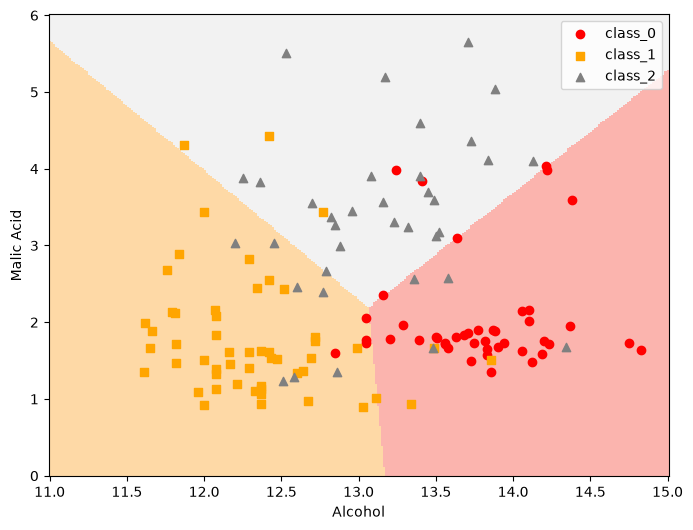

In [18]:
import matplotlib.pyplot as plt
#from matplotlib import colors

plt.figure(figsize=(8,6))

plt.pcolormesh(xx1, xx2, clss, cmap="Pastel1")  #Create a pseudocolor plot with a non-regular rectangular grid.

df = pd.DataFrame(X_tn, columns = raw_wine["feature_names"][:2])
df['target'] = y_tn
markers = ['o', 's', '^']
colors = ["red", "orange", "grey"]

for i, mark in enumerate(markers):
    X_i = df[df['target'] == i]
    class_i = raw_wine.target_names[i]
    plt.scatter(X_i["alcohol"], X_i["malic_acid"], marker = mark, label = class_i, color = colors[i])
    
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
    
    
plt.legend()    
plt.show()

아래는 산점도만 test set으로 바꾸었다.

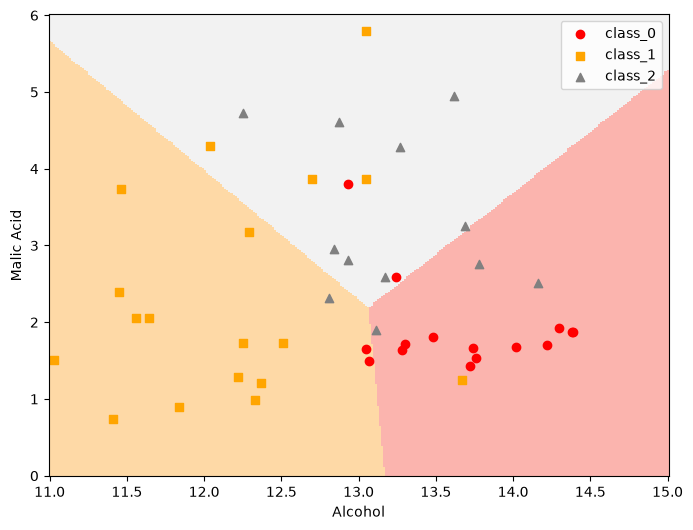

In [19]:
# Using test set
plt.figure(figsize=(8,6))

plt.pcolormesh(xx1, xx2, clss, cmap="Pastel1")  #Create a pseudocolor plot with a non-regular rectangular grid.

df = pd.DataFrame(X_te, columns = raw_wine["feature_names"][:2])
df['target'] = y_te
markers = ['o', 's', '^']
colors = ["red", "orange", "grey"]


for i, mark in enumerate(markers):
    X_i = df[df['target'] == i]
    class_i = raw_wine.target_names[i]
    plt.scatter(X_i["alcohol"], X_i["malic_acid"], marker = mark, label = class_i, color = colors[i])
    
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
    
plt.legend()    
plt.show()

한편, `.decision_function`을 이용하면 discriminant score를 계산해 볼 수 있다.

내부적으로는 discriminant score를 계산한 후, softmax를 이용해 각 클래스에 속할 확률을 계산한다. (다중 클래스에서는 각 클래스에 대한 discriminant score가 반환되지만, 이진 분류의 경우 `decision_function`은 하나의 스칼라 값만 반환한다는 점에 유의하자.)

In [20]:
lda.decision_function(X_te[:5, :])

array([[-4.11794297,  0.77374852, -4.16754116],
       [-1.92465836, -1.75294827, -3.12836318],
       [-8.45566304,  4.28970115, -4.0421469 ],
       [ 2.14042887, -5.87860883, -2.02291397],
       [-4.06525316,  0.51175298, -3.84622417]])

모형 추정치들을 직접 확인하려면 다음을 활용한다.

In [21]:
# 각 클래스에 대한 평균 벡터
lda.means_

array([[13.77409091,  2.05113636],
       [12.31924528,  1.7854717 ],
       [13.13555556,  3.34333333]])

In [22]:
# 각 클래스에 속할 사전 확률 = 클래스 비율
lda.priors_

array([0.33082707, 0.39849624, 0.27067669])

공분산 행렬의 추정치는 `solver='lsqr'` 혹은 `solver='eigen'`으로 생성했을 때 가능하다. (`solver='svd'`를 사용할 경우에는 `store_covariance=True`를 추가로 지정해야 하며, `lsqr`/`eigen`은 계산 과정에서 공분산을 이미 구하므로 `store_covariance` 설정과 무관하게 `covariance_` 속성을 사용할 수 있다.) 참고로 `covariance_`는 편향 추정량(biased estimator, 분모가 $n$)을 사용하여 계산되므로, 앞서 살펴본 불편 추정 공식(분모 $n-K$)과는 정확히 일치하지 않을 수 있다.

In [23]:
LinearDiscriminantAnalysis(solver='lsqr', store_covariance=True).fit(X_tn, y_tn).covariance_

array([[0.23041445, 0.00487179],
       [0.00487179, 0.74204478]])

LDA 예측 결과를 분석해 보자.

In [24]:
pred_by_LDA = lda.predict(X_te)
print(pred_by_LDA)

[1 1 1 0 1 0 1 1 1 0 0 2 0 1 0 2 2 0 2 0 1 1 0 0 0 0 2 2 2 2 1 0 1 1 1 2 1
 2 2 2 0 2 1 0 2]


In [25]:
print(y_te)

[1 0 1 0 1 0 1 1 1 0 0 0 2 1 0 2 2 0 1 0 1 1 0 0 2 2 2 2 2 1 1 0 0 1 2 1 1
 2 1 2 1 0 1 0 2]


[classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)를 통해 각 클래스별 precision, recall, f1-score를 확인할 수 있다.

F1-score는 precision과 recall의 조화평균(harmonic mean)으로, 두 지표를 하나의 값으로 요약해서 비교할 때 사용한다.

$$ F_1 = 2 \frac{precision \times recall}{precision + recall} = \frac{TP}{ TP + 0.5 (FP + FN) }$$

In [26]:
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_by_LDA)
print(class_report)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73        15
           1       0.81      0.72      0.76        18
           2       0.57      0.67      0.62        12

    accuracy                           0.71        45
   macro avg       0.71      0.71      0.70        45
weighted avg       0.72      0.71      0.71        45



In [27]:
# precision for 0 class
sum((y_te==0) & (pred_by_LDA==0)) / sum(pred_by_LDA==0)

np.float64(0.7333333333333333)

In [28]:
# precision for 1 class
sum((y_te==1) & (pred_by_LDA==1)) / sum(pred_by_LDA==1)

np.float64(0.8125)

In [29]:
# precision for 2 class
sum((y_te==2) & (pred_by_LDA==2)) / sum(pred_by_LDA==2)

np.float64(0.5714285714285714)

In [30]:
# recall for 0 class
sum((y_te==0) & (pred_by_LDA==0)) / sum(y_te==0)

np.float64(0.7333333333333333)

In [31]:
# recall for 1 class
sum((y_te==1) & (pred_by_LDA==1)) / sum(y_te==1)

np.float64(0.7222222222222222)

In [32]:
# recall for 2 class
sum((y_te==2) & (pred_by_LDA==2)) / sum(y_te==2)

np.float64(0.6666666666666666)

In [33]:
# accuracy
(sum((y_te==0) & (pred_by_LDA==0)) + sum((y_te==1) & (pred_by_LDA==1)) + sum((y_te==2) & (pred_by_LDA==2))) / len(y_te)

np.float64(0.7111111111111111)

```sklearn.metrics```의 [```accuracy_score```](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)를 이용하여 예측 정확성을 계산할 수 있다.

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_te, lda.predict(X_te))

0.7111111111111111

다음으로도 가능하다.

In [35]:
lda.score(X_te, y_te)

0.7111111111111111

## 표준화

모형에 따라서는 훈련 데이터를 표준화하여 훈련하면 성능 향상을 기대할 수 있다. (다만 LDA는 아래에서 보듯이 표준화에 따른 성능 변화가 크지 않은 경우가 많다.)  

[```sklearn.preprocessing.StandardScaler```](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)를 이용하면 쉽게 표준화할 수 있다.  

- $X$의 값들만 표준화하면 된다.

- $X$의 훈련 데이터를 `StandardScaler`에 `fit()` 한 후, `transform()` method를 훈련 데이터와 테스트 데이터에 적용한다.

- 표준화는 **전처리 단계**의 일종으로 `sklearn`에서 전처리 클래스들은 일반적으로 `fit()` -> `transform()`의 단계로 수행된다.

  - 혹은 합쳐서 `fit_transform()` <br><br>

- 반면 모델(estimator)들은 보통 `fit()` -> `predict()`의 단계로 수행된다는 점이 다름.

In [36]:
# 표준화
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [37]:
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [38]:
#평균은 0이 되고, 표준편차는 1이 된다.
X_tn_std[:,0].mean(), X_tn_std[:,0].std(), X_tn_std[:,1].mean(), X_tn_std[:,1].std()

(np.float64(1.2534668374264174e-14),
 np.float64(0.9999999999999999),
 np.float64(4.941744590812727e-16),
 np.float64(0.9999999999999996))

모델 fitting할 때 표준화된 훈련 세트를 이용해 보자.

In [39]:
lda_std = LinearDiscriminantAnalysis()
lda_std.fit(X_tn_std, y_tn)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[int64](3,)","[0,1,2]"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float64](3, 2)","[[ 2.52,-0.37], [-2.33,-0.7 ], [ 0.36, 1.49]]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If ``n_components`` is not set then all components are stored and thesum of explained variances is equal to 1.0. Only available when eigenor svd solver is used.","ndarray[float64](2,)","[0.77,0.23]"


앞에서처럼 예측 정확성을 평가해 보자. LDA의 판별 함수는 각 클래스 평균과 (역행렬을 취한) 공통 공분산 행렬에 대한 선형 함수이므로, 표준화와 같은 가역적 선형 변환을 거쳐도 클래스 간 판별 결과(그리고 정확도)가 크게 달라지지 않는 경우가 많다.

In [40]:
# 표준화된 테스트 세트를 이용
from sklearn.metrics import accuracy_score
accuracy_score(y_te, lda_std.predict(X_te_std))

0.7111111111111111

In [41]:
lda_std.score(X_te_std, y_te)

0.7111111111111111

## 다른 형태의 discriminant analysis

-------------------------------

* $f_k(x)$가 Gaussian이며 $\Sigma_{k}$가 각 클래스 별로 다를 경우, quadratic discriminant analysis라고 한다.

* $f_k(x) = \prod_{j=1}^{p} f_{jk}(x_j)$, 즉, $x$들이 조건부 독립일 때, 이를 naive Bayes라고 한다.

* 그 외에, $f_k$를 어떻게 정의하느냐에 따라 다양한 discriminant analysis form이 존재할 수 있다.

### Quadratic discriminant analysis

$$ \delta_k(x) = -\frac{1}{2} (x - \mu_k)^{\top} \Sigma_{k}^{-1} (x - \mu_k) - \frac{1}{2}\log |\Sigma_k| + \log \pi_k $$

$k$에 따라 $\Sigma_{k}$가 다르기 때문에, quadratic 형태의 곡선(또는 곡면)이 경계선으로 나타난다.

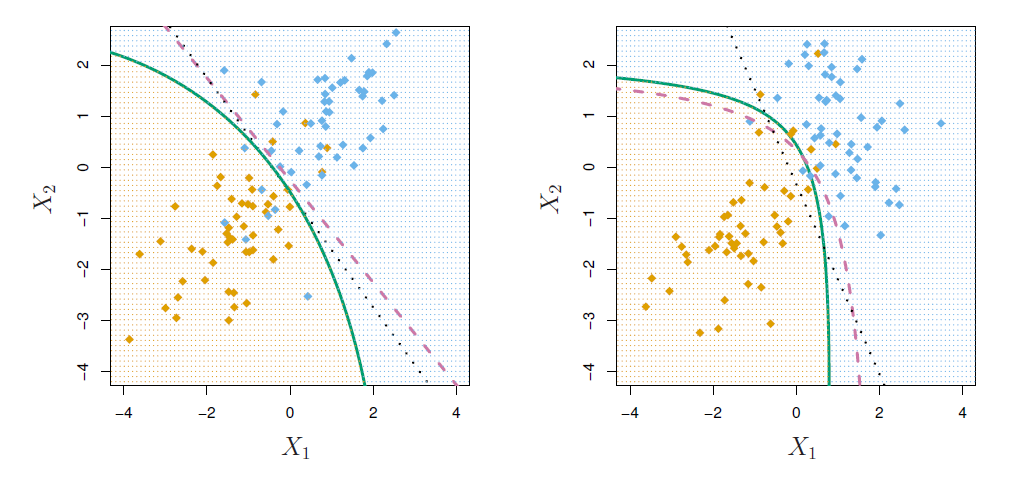

[```sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis```](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis.html)를 이용하여 quadratic discriminant analysis를 진행해 보자.

In [42]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis()

qda.fit(X_tn, y_tn)

clss = qda.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

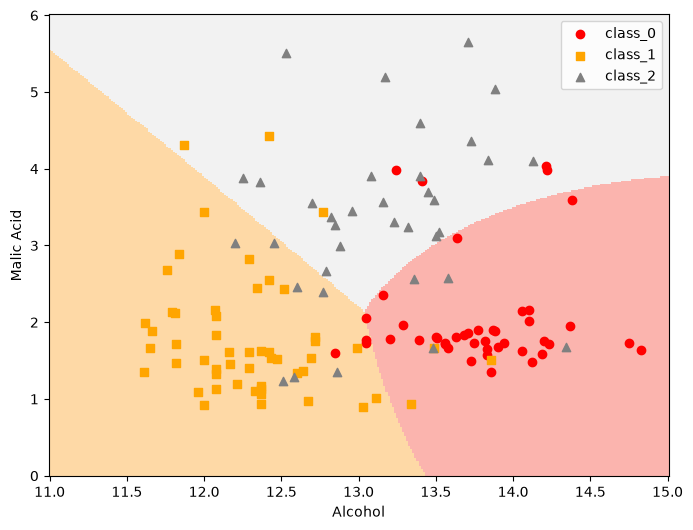

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.pcolormesh(xx1, xx2, clss, cmap="Pastel1")  #Create a pseudocolor plot with a non-regular rectangular grid.

df = pd.DataFrame(X_tn, columns = raw_wine["feature_names"][:2])
df['target'] = y_tn
markers = ['o', 's', '^']
colors = ["red", "orange", "grey"]

for i, mark in enumerate(markers):
    X_i = df[df['target'] == i]
    class_i = raw_wine.target_names[i]
    plt.scatter(X_i["alcohol"], X_i["malic_acid"], marker = mark, label = class_i, color = colors[i])
    
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
    
    
plt.legend()    
plt.show()

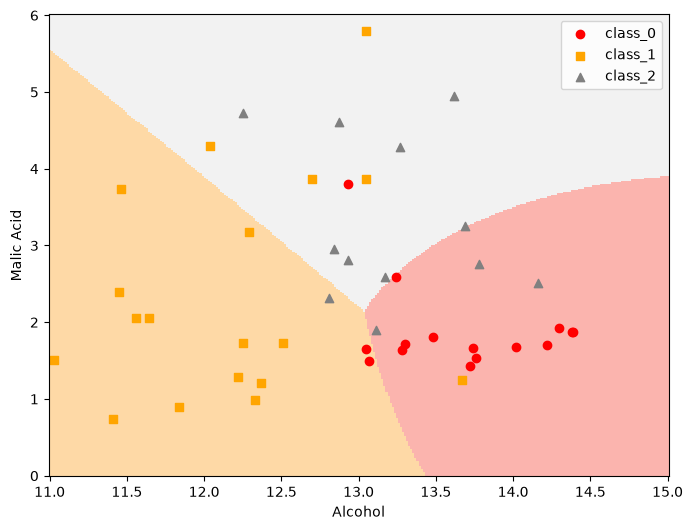

In [44]:
plt.figure(figsize=(8,6))

plt.pcolormesh(xx1, xx2, clss, cmap="Pastel1")  #Create a pseudocolor plot with a non-regular rectangular grid.

df = pd.DataFrame(X_te, columns = raw_wine["feature_names"][:2])
df['target'] = y_te
markers = ['o', 's', '^']
colors = ["red", "orange", "grey"]

for i, mark in enumerate(markers):
    X_i = df[df['target'] == i]
    class_i = raw_wine.target_names[i]
    plt.scatter(X_i["alcohol"], X_i["malic_acid"], marker = mark, label = class_i, color = colors[i])
    
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
    
    
plt.legend()    
plt.show()

In [45]:
class_report = classification_report(y_te, qda.predict(X_te))
print(class_report)

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.81      0.72      0.76        18
           2       0.62      0.67      0.64        12

    accuracy                           0.73        45
   macro avg       0.73      0.73      0.73        45
weighted avg       0.74      0.73      0.73        45



In [46]:
# 각 클래스별 평균
qda.means_

array([[13.77409091,  2.05113636],
       [12.31924528,  1.7854717 ],
       [13.13555556,  3.34333333]])

In [47]:
qda.priors_

array([0.33082707, 0.39849624, 0.27067669])

추정된 covariance matrix를 보고 싶다면 `store_covariance=True`를 이용해야 한다.

In [48]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_tn, y_tn).covariance_

[array([[0.1994759 , 0.01072082],
        [0.01072082, 0.51854519]]),
 array([[ 0.22989557, -0.07993041],
        [-0.07993041,  0.63295602]]),
 array([[0.2889454 , 0.12409524],
        [0.12409524, 1.24230857]])]

### Naive Bayes

$X$들이 (각 클래스 내에서) 조건부로 독립이라고 가정한 경우를 Naive Bayes라고 부른다.

$p$가 커서 각 클래스별 공분산 행렬을 추정하기 어려운 경우에도, 비교적 적은 모수로 안정적인 추정이 가능해 유용할 수 있다.

$\Sigma_k$는 클래스 별로 다를 수 있다고 가정한다.

Gaussian naive Bayes에서는 정규분포를 가정하며, $\Sigma_k$가 대각 행렬이 된다. 따라서

$$ \delta_k(x) = \log \left[ \pi_k \prod_{j=1}^{p} f_{kj}(x_j) \right] = -\frac{1}{2} \sum_{j=1}^{p} \left[ \frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2} + \log(2\pi\sigma_{kj}^2) \right] + \log \pi_k $$

Naive Bayes 방법은 $x$가 질적 변수, 양적 변수가 섞여 있을 경우로도 확장할 수 있다.

만약 $X_j$가 질적 변수라면, $f_{kj}(x_j)$ 대신 probability mass function을 적용한다.

Naive Bayes는 강한 조건을 가정하지만, 비교적 좋은 분류 결과를 얻는 경향이 있다고 한다. 다만 아래에서 사용할 `sklearn.naive_bayes.GaussianNB`는 모든 특성이 연속형이고 정규분포를 따른다고 가정하는 구현체이며, 질적 변수가 섞인 경우는 지원하지 않는다 (범주형 변수에는 `CategoricalNB` 등 다른 구현체를 사용해야 한다).

[`sklearn.naive_bayes.GaussianNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)를 이용하여 보자.

In [49]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_tn, y_tn)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[44.,53.,36.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.4 ,0.27]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.163e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 2)","[[13.77, 2.05], [12.32, 1.79], [13.14, 3.34]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 2)","[[0.19,0.51], [0.23,0.62], [0.28,1.21]]"


In [50]:
pred_by_gnb = gnb.predict(X_te)
print(pred_by_gnb)

[1 1 1 0 1 0 1 1 1 0 0 2 0 1 0 2 2 0 2 0 1 1 0 0 0 0 2 2 2 2 1 0 1 1 1 2 1
 2 2 2 0 0 1 0 2]


In [51]:
class_report_gnb = classification_report(y_te, pred_by_gnb)
print(class_report_gnb)

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.81      0.72      0.76        18
           2       0.62      0.67      0.64        12

    accuracy                           0.73        45
   macro avg       0.73      0.73      0.73        45
weighted avg       0.74      0.73      0.73        45



In [52]:
Z = gnb.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])   

clss = gnb.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

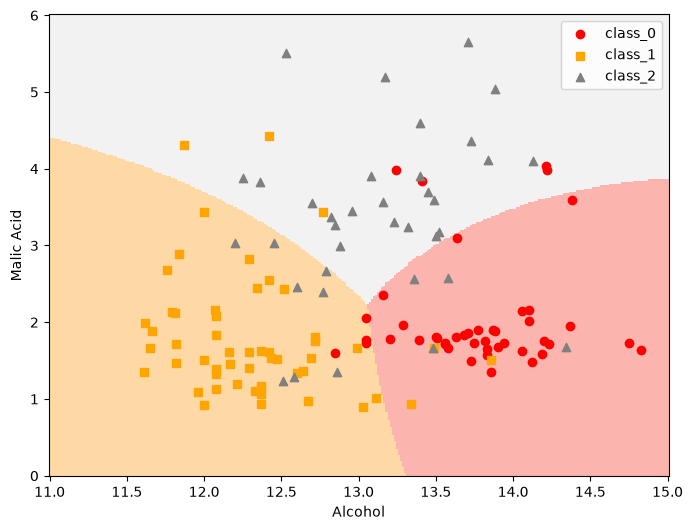

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8,6))

plt.pcolormesh(xx1, xx2, clss, cmap="Pastel1")  

df = pd.DataFrame(X_tn, columns = raw_wine["feature_names"][:2])
df['target'] = y_tn
markers = ['o', 's', '^']
colors = ["red", "orange", "grey"]


for i, mark in enumerate(markers):
    X_i = df[df['target'] == i]
    class_i = raw_wine.target_names[i]
    plt.scatter(X_i["alcohol"], X_i["malic_acid"], marker = mark, label = class_i, color = colors[i])

plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
    
plt.legend()    
plt.show()

추정치들도 체크해 볼 수 있다.

In [54]:
gnb.class_prior_

array([0.33082707, 0.39849624, 0.27067669])

In [55]:
gnb.theta_

array([[13.77409091,  2.05113636],
       [12.31924528,  1.7854717 ],
       [13.13555556,  3.34333333]])

In [56]:
gnb.var_

array([[0.19494236, 0.50676007],
       [0.22555792, 0.62101346],
       [0.28091914, 1.2078    ]])